# Bagging (BG) on the MHAR 5-min Feature Set


**Purpose:** The purpose of this notebook is to compute the out-of-sample forecast performance of the Bagging (BG) model on the $\mathcal{M}_{\mathrm{HAR}}$ 5-min feature set for the EURO STOXX 50 index over the period 1999--2020, following the methodology of Christensen et al. (2023).

The Bagging model builds on regression trees by averaging across a large number of bootstrapped trees. Compared with a single regression tree, bagging reduces estimation variance by repeatedly fitting the same base learner on different bootstrap samples and aggregating the resulting predictions. In contrast to Random Forest, bagging does not impose random feature selection at each split.

The baseline forecasting relation is written as:

$$
RV_{t+1} = f(Z_t) + \varepsilon_{t+1},
$$

where $Z_t$ consists of the MHAR predictors:

- $RV_t$ (RVD) — daily realized variance  
- $\overline{RV}_t^{(w)} = \frac{1}{5}\sum_{i=0}^{4} RV_{t-i}$ (RVW) — 5-day rolling average of realized variance  
- $\overline{RV}_t^{(m)} = \frac{1}{22}\sum_{i=0}^{21} RV_{t-i}$ (RVM) — 22-day rolling average of realized variance  

The bagging predictor is obtained by averaging over $B$ regression trees:

$$
\hat f(Z_t) = \frac{1}{B}\sum_{b=1}^{B} \hat f_b(Z_t),
$$

where each tree is estimated on a bootstrap sample of the data. In line with the paper, Bagging is treated as an off-the-shelf tree-based model, so no separate hyperparameter tuning is performed. Instead, the ensemble is re-estimated in a fixed-length rolling window using the combined training and validation sample available at each forecast origin.


## 1. Loading Data
Loading in data from the `MALL_5min.csv` file.


In [4]:
import pandas as pd
import numpy as np
import os
import time
import matplotlib.pyplot as plt
from sklearn.ensemble import BaggingRegressor
from sklearn.tree import DecisionTreeRegressor

# Load MALL dataset
file_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/MALL_5min.csv"
MALL = pd.read_csv(file_path, index_col="Date", parse_dates=True)

print(f"Shape: {MALL.shape}")
print(f"Date range: {MALL.index[0].date()} to {MALL.index[-1].date()}")
print(f"NaN values: {MALL.isna().sum().sum()}")
MALL.head()


Shape: (5489, 31)
Date range: 1999-01-05 to 2020-08-06
NaN values: 0


,RVD,RVW,RVM,logRVD,logRVW,logRVM,RVD_pos,RVD_neg,RD_neg,RW_neg,...,BRENT,BRENT_ret,NIKKEI_ret,NIKKEI_sq,SP500_ret_lag,SP500_sq_lag,M1W,M1M,RV_target,logRV_target
Date,,,,,,,,,,,,,,,,,,,,,
1999-01-05,0.000106,0.000089,0.000141,-9.153100,-9.328531,-8.866447,0.000071,0.000035,0.000000,0.000000,...,10.30,-0.060282,-0.013746,0.000189,-0.000920,8.458434e-07,0.087690,0.126206,0.000047,-9.966398
1999-01-06,0.000047,0.000090,0.000132,-9.966398,-9.316927,-8.935760,0.000038,0.000009,0.000000,0.000000,...,10.67,0.035292,0.017657,0.000312,0.013491,1.819949e-04,0.100143,0.187219,0.000237,-8.347779
1999-01-07,0.000237,0.000123,0.000131,-8.347779,-9.004761,-8.938374,0.000110,0.000127,-0.012859,0.000000,...,11.08,0.037706,0.005044,0.000025,0.021899,4.795626e-04,0.078881,0.184020,0.000168,-8.689606
1999-01-08,0.000168,0.000146,0.000114,-8.689606,-8.832472,-9.082830,0.000079,0.000089,-0.005883,0.000000,...,11.70,0.054447,-0.010751,0.000116,-0.002053,4.216638e-06,0.078883,0.165510,0.000282,-8.175339
1999-01-11,0.000282,0.000168,0.000117,-8.175339,-8.692020,-9.056351,0.000067,0.000215,-0.025309,-0.001398,...,12.07,0.031134,-0.001744,0.000003,0.004212,1.774503e-05,0.001055,0.140613,0.000191,-8.565468


## 2. Data Split
### 2.1 Train / Validation / Test Split (70 / 10 / 20)


Following Christensen et al. (2023), we split the sample into a training set (70%), validation set (10%), and test set (20%). For the off-the-shelf Bagging implementation, the training and validation blocks are then combined into a single rolling estimation window used to generate one-day-ahead test-set forecasts.


In [8]:
# Train / Validation / Test split (70 / 10 / 20)
n = len(MALL)
n_train = int(np.floor(0.70 * n))
n_val = int(np.floor(0.10 * n))
n_test = n - n_train - n_val

print(f"Training observations:   {n_train}")
print(f"Validation observations: {n_val}")
print(f"Test observations:       {n_test}")

print(f"Training period:   {MALL.index[0].date()} to {MALL.index[n_train - 1].date()}")
print(f"Validation period: {MALL.index[n_train].date()} to {MALL.index[n_train + n_val - 1].date()}")
print(f"Test period:       {MALL.index[n_train + n_val].date()} to {MALL.index[-1].date()}")


Training observations:   3842
Validation observations: 548
Test observations:       1099
Training period:   1999-01-05 to 2014-02-26
Validation period: 2014-02-27 to 2016-04-20
Test period:       2016-04-21 to 2020-08-06


## 3. Bagging
### 3.1 Model Specification


The Bagging model replaces the linear HAR forecasting equation with an ensemble of regression trees estimated on bootstrap resamples. Since the predictors are only `RVD`, `RVW`, and `RVM`, the model remains compact, but it can still capture nonlinear threshold effects and interaction patterns across the realized-volatility measures.


### 3.2 Feature Set Construction
Extracting the dependent and independent variables relevant for the BG model.


In [13]:
# Define target and MHAR feature set
y = MALL["RV_target"].values
X_MHAR = MALL[["RVD", "RVW", "RVM"]].values

# Split into train, validation and test sets
X_train = X_MHAR[:n_train]
X_val = X_MHAR[n_train:n_train + n_val]
X_test = X_MHAR[n_train + n_val:]

y_train = y[:n_train]
y_val = y[n_train:n_train + n_val]
y_test = y[n_train + n_val:]

# Standardize predictors using training-sample moments for consistency across notebooks
X_mean = X_train.mean(axis=0)
X_std = X_train.std(axis=0, ddof=0)
X_std = np.where(X_std == 0, 1.0, X_std)

X_scaled = (X_MHAR - X_mean) / X_std
X_train_scaled = X_scaled[:n_train]
X_val_scaled = X_scaled[n_train:n_train + n_val]
X_test_scaled = X_scaled[n_train + n_val:]

print("Feature set: RVD, RVW, RVM")
print(f"\nFull dataset:   X={X_scaled.shape}, y={y.shape}")
print(f"Training set:   X={X_train_scaled.shape}, y={y_train.shape}")
print(f"Validation set: X={X_val_scaled.shape}, y={y_val.shape}")
print(f"Test set:       X={X_test_scaled.shape}, y={y_test.shape}")
print("\nStandardization check on training sample:")
print(f"  Means: {X_train_scaled.mean(axis=0).round(6)}")
print(f"  Std:   {X_train_scaled.std(axis=0).round(6)}")


Feature set: RVD, RVW, RVM

Full dataset:   X=(5489, 3), y=(5489,)
Training set:   X=(3842, 3), y=(3842,)
Validation set: X=(548, 3), y=(548,)
Test set:       X=(1099, 3), y=(1099,)

Standardization check on training sample:
  Means: [ 0. -0. -0.]
  Std:   [1. 1. 1.]


## 5. Bagging Model Specification

Following Christensen et al. (2023), Bagging is treated as an off-the-shelf tree-based model rather than a heavily tuned learner. The ensemble is therefore estimated with a fixed parameter configuration and then re-estimated across rolling windows over the test period.


In [16]:
# Bagging settings following the paper-style off-the-shelf implementation
base_tree = DecisionTreeRegressor(min_samples_leaf=5, random_state=42)

bg_params = {
    "estimator": base_tree,
    "n_estimators": 500,
    "bootstrap": True,
    "random_state": 42,
    "n_jobs": 1
}

print("Bagging parameters:")
for key, value in bg_params.items():
    print(f"  {key}: {value}")

bg_initial = BaggingRegressor(**bg_params)
bg_initial.fit(X_scaled[:n_train + n_val], y[:n_train + n_val])

initial_importance = pd.Series(
    np.mean([tree.feature_importances_ for tree in bg_initial.estimators_], axis=0),
    index=["RVD", "RVW", "RVM"]
)

display(initial_importance.sort_values(ascending=False).to_frame("Initial feature importance"))


Bagging parameters:
  estimator: DecisionTreeRegressor(min_samples_leaf=5, random_state=42)
  n_estimators: 500
  bootstrap: True
  random_state: 42
  n_jobs: 1


,Initial feature importance
RVD,0.622671
RVW,0.306066
RVM,0.071263


## 6. Rolling Window Estimation and Forecasting

Each forecast is formed one day ahead using a rolling estimation window of length equal to the initial training plus validation sample. Since Bagging is treated as an off-the-shelf learner, the ensemble is simply re-estimated in each window without separate hyperparameter tuning.


In [18]:
window_size = n_train + n_val

print(f"Rolling window length (train + validation): {window_size}")

forecasts_BG = []
dates_test = []
importance_path = []

start_time = time.time()

for i in range(n_test):
    X_window = X_scaled[i:i + window_size]
    y_window = y[i:i + window_size]

    model_final = BaggingRegressor(**bg_params)
    model_final.fit(X_window, y_window)

    X_forecast = X_scaled[i + window_size].reshape(1, -1)
    forecast = model_final.predict(X_forecast)[0]

    # Paper-consistent floor for negative volatility forecasts
    min_rv_roll = y_window.min()
    forecast = max(forecast, min_rv_roll)

    forecasts_BG.append(forecast)
    dates_test.append(MALL.index[i + window_size])
    importance_path.append(np.mean([tree.feature_importances_ for tree in model_final.estimators_], axis=0))

    if (i + 1) % 100 == 0:
        elapsed = (time.time() - start_time) / 60
        print(f"  Day {i + 1:4d}/{n_test} | Date: {MALL.index[i + window_size].date()} | Elapsed: {elapsed:.1f} min")

total_elapsed = (time.time() - start_time) / 60
print(f"\nTotal estimation time: {total_elapsed:.1f} minutes")
print(f"Forecasts generated: {len(forecasts_BG)}")
print(f"Forecast period: {dates_test[0].date()} to {dates_test[-1].date()}")

avg_importance = pd.Series(
    np.mean(np.vstack(importance_path), axis=0),
    index=["RVD", "RVW", "RVM"]
)
print("\nAverage feature importance across rolling windows:")
display(avg_importance.sort_values(ascending=False).to_frame("Average importance"))


Rolling window length (train + validation): 4390
  Day  100/1099 | Date: 2016-09-08 | Elapsed: 6.0 min
  Day  200/1099 | Date: 2017-01-27 | Elapsed: 12.0 min
  Day  300/1099 | Date: 2017-06-21 | Elapsed: 17.9 min
  Day  400/1099 | Date: 2017-11-08 | Elapsed: 23.7 min
  Day  500/1099 | Date: 2018-04-04 | Elapsed: 29.6 min
  Day  600/1099 | Date: 2018-08-22 | Elapsed: 35.6 min
  Day  700/1099 | Date: 2019-01-14 | Elapsed: 41.6 min
  Day  800/1099 | Date: 2019-06-06 | Elapsed: 47.6 min
  Day  900/1099 | Date: 2019-10-24 | Elapsed: 53.6 min
  Day 1000/1099 | Date: 2020-03-17 | Elapsed: 59.8 min

Total estimation time: 65.9 minutes
Forecasts generated: 1099
Forecast period: 2016-04-21 to 2020-08-06

Average feature importance across rolling windows:


,Average importance
RVD,0.692847
RVW,0.233235
RVM,0.073918


## 7. Save Forecasts

The forecasts and summary metrics are stored using the same file structure as the benchmark, regularized-model, and other tree-based notebooks so they can be reused in downstream model-comparison work.


In [22]:
import os

# --- Define paths ---
forecast_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/Forecasts 5-min/MHAR/Tree-based Models"
mse_path = "/Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/MSE 5-min/MHAR/Tree-based Models"

os.makedirs(forecast_path, exist_ok=True)
os.makedirs(mse_path, exist_ok=True)

# --- Construct results dataframe ---
results_BG = pd.DataFrame({
    "RV_actual": y_test,
    "RV_forecast": forecasts_BG
}, index=dates_test)

# --- Compute errors ---
errors_BG = results_BG["RV_actual"] - results_BG["RV_forecast"]
mse_BG = np.mean(errors_BG ** 2)

# --- Save forecasts ---
results_BG.to_csv(os.path.join(forecast_path, "forecasts_BG.csv"))

# --- Save MSE summary ---
mse_summary_BG = pd.DataFrame({
    "Model": ["BG"],
    "MSE": [mse_BG],
    "RMSE": [np.sqrt(mse_BG)],
    "MAE": [errors_BG.abs().mean()],
    "Mean_Error": [errors_BG.mean()],
}).set_index("Model")

mse_summary_BG.to_csv(os.path.join(mse_path, "mse_summary_BG.csv"))

# --- Print summary ---
print(f"Forecasts saved to: {forecast_path}")
print(f"MSE summary saved to: {mse_path}")
print(f"Rows saved: {len(results_BG)}")
print(f"Bagging test-set MSE: {mse_BG:.6e}")


Forecasts saved to: /Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/Forecasts 5-min/MHAR/Tree-based Models
MSE summary saved to: /Users/tobiasbergdahlpersson/Documents/SSE/MSc Thesis/5-min RV/Cleaned Data Sets/MSE 5-min/MHAR/Tree-based Models
Rows saved: 1099
Bagging test-set MSE: 5.327397e-08


## 4. Results
### 4.1 Forecast Visualization


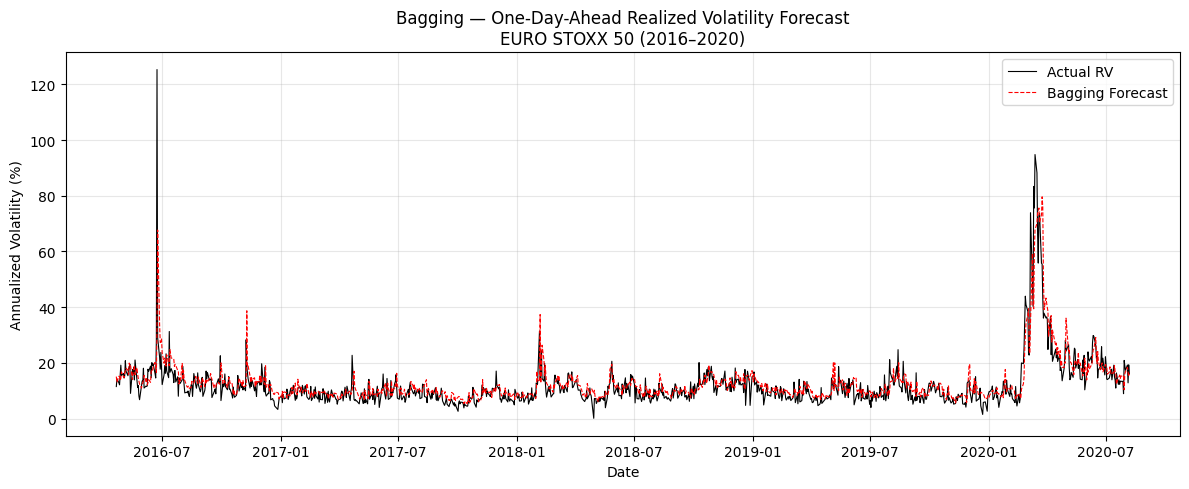


Summary of forecast errors:
Mean error:  -2.414245e-06
RMSE:        2.308116e-04
MAE:         4.822940e-05


In [25]:
import matplotlib.pyplot as plt

# Convert to annualized volatility for readability
results_plot = pd.DataFrame({
    "Actual": np.sqrt(results_BG["RV_actual"] * 252) * 100,
    "Forecast": np.sqrt(results_BG["RV_forecast"] * 252) * 100
}, index=results_BG.index)

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(results_plot["Actual"], label="Actual RV", color="black", linewidth=0.8)
ax.plot(results_plot["Forecast"], label="Bagging Forecast", color="red", linewidth=0.8, linestyle="--")
ax.set_title("Bagging — One-Day-Ahead Realized Volatility Forecast\nEURO STOXX 50 (2016–2020)", fontsize=12)
ax.set_ylabel("Annualized Volatility (%)")
ax.set_xlabel("Date")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\nSummary of forecast errors:")
errors = results_BG["RV_actual"] - results_BG["RV_forecast"]
print(f"Mean error:  {errors.mean():.6e}")
print(f"RMSE:        {np.sqrt(mse_BG):.6e}")
print(f"MAE:         {errors.abs().mean():.6e}")
